Seed set to 42


Using device: Apple Metal (MPS)
Epoch 10, train_loss: 0.0563, val_loss: 0.0403
Epoch 20, train_loss: 0.0272, val_loss: 0.0273
Epoch 30, train_loss: 0.0185, val_loss: 0.0281
Epoch 40, train_loss: 0.0144, val_loss: 0.0274
Epoch 50, train_loss: 0.0125, val_loss: 0.0202
Epoch 60, train_loss: 0.0112, val_loss: 0.0143
Epoch 70, train_loss: 0.0101, val_loss: 0.0246
Epoch 80, train_loss: 0.0099, val_loss: 0.0198
Epoch 90, train_loss: 0.0092, val_loss: 0.0196
Epoch 100, train_loss: 0.0090, val_loss: 0.0184
Epoch 110, train_loss: 0.0082, val_loss: 0.0216
Epoch 120, train_loss: 0.0078, val_loss: 0.0198
Epoch 130, train_loss: 0.0070, val_loss: 0.0167
Epoch 140, train_loss: 0.0068, val_loss: 0.0177
Epoch 150, train_loss: 0.0064, val_loss: 0.0148
Epoch 160, train_loss: 0.0059, val_loss: 0.0209
Epoch 170, train_loss: 0.0055, val_loss: 0.0172
Epoch 180, train_loss: 0.0049, val_loss: 0.0181
Epoch 190, train_loss: 0.0042, val_loss: 0.0179
Epoch 200, train_loss: 0.0040, val_loss: 0.0157
Epoch 210, train_

Seed set to 42


Early stopping at epoch 348 (best_val_loss=0.0122)
MSE: 29170.15
RMSE: 170.79
MAE: 121.64
MAPE: 7.42%
R²: -1.3708
Using device: Apple Metal (MPS)
Epoch 10, train_loss: 0.0577, val_loss: 0.0273
Epoch 20, train_loss: 0.0296, val_loss: 0.0140
Epoch 30, train_loss: 0.0189, val_loss: 0.0135
Epoch 40, train_loss: 0.0155, val_loss: 0.0150
Epoch 50, train_loss: 0.0141, val_loss: 0.0152
Epoch 60, train_loss: 0.0117, val_loss: 0.0135
Epoch 70, train_loss: 0.0109, val_loss: 0.0084
Epoch 80, train_loss: 0.0096, val_loss: 0.0090
Epoch 90, train_loss: 0.0088, val_loss: 0.0084
Epoch 100, train_loss: 0.0088, val_loss: 0.0090
Epoch 110, train_loss: 0.0082, val_loss: 0.0086
Epoch 120, train_loss: 0.0081, val_loss: 0.0082
Epoch 130, train_loss: 0.0080, val_loss: 0.0081
Epoch 140, train_loss: 0.0068, val_loss: 0.0101
Epoch 150, train_loss: 0.0065, val_loss: 0.0111
Epoch 160, train_loss: 0.0066, val_loss: 0.0075
Epoch 170, train_loss: 0.0057, val_loss: 0.0080
Epoch 180, train_loss: 0.0051, val_loss: 0.0080

Seed set to 42


Early stopping at epoch 244 (best_val_loss=0.0047)
MSE: 240220.69
RMSE: 490.12
MAE: 355.55
MAPE: 15.85%
R²: -0.7004
Using device: Apple Metal (MPS)
Epoch 10, train_loss: 0.0650, val_loss: 0.0071
Epoch 20, train_loss: 0.0331, val_loss: 0.0035
Epoch 30, train_loss: 0.0234, val_loss: 0.0059
Epoch 40, train_loss: 0.0171, val_loss: 0.0026
Epoch 50, train_loss: 0.0157, val_loss: 0.0019
Epoch 60, train_loss: 0.0132, val_loss: 0.0041
Epoch 70, train_loss: 0.0134, val_loss: 0.0041
Epoch 80, train_loss: 0.0117, val_loss: 0.0037
Epoch 90, train_loss: 0.0111, val_loss: 0.0020
Epoch 100, train_loss: 0.0097, val_loss: 0.0025
Epoch 110, train_loss: 0.0092, val_loss: 0.0022
Epoch 120, train_loss: 0.0099, val_loss: 0.0045
Epoch 130, train_loss: 0.0089, val_loss: 0.0036
Epoch 140, train_loss: 0.0086, val_loss: 0.0027
Epoch 150, train_loss: 0.0080, val_loss: 0.0036
Epoch 160, train_loss: 0.0075, val_loss: 0.0033
Epoch 170, train_loss: 0.0073, val_loss: 0.0041
Epoch 180, train_loss: 0.0070, val_loss: 0.00

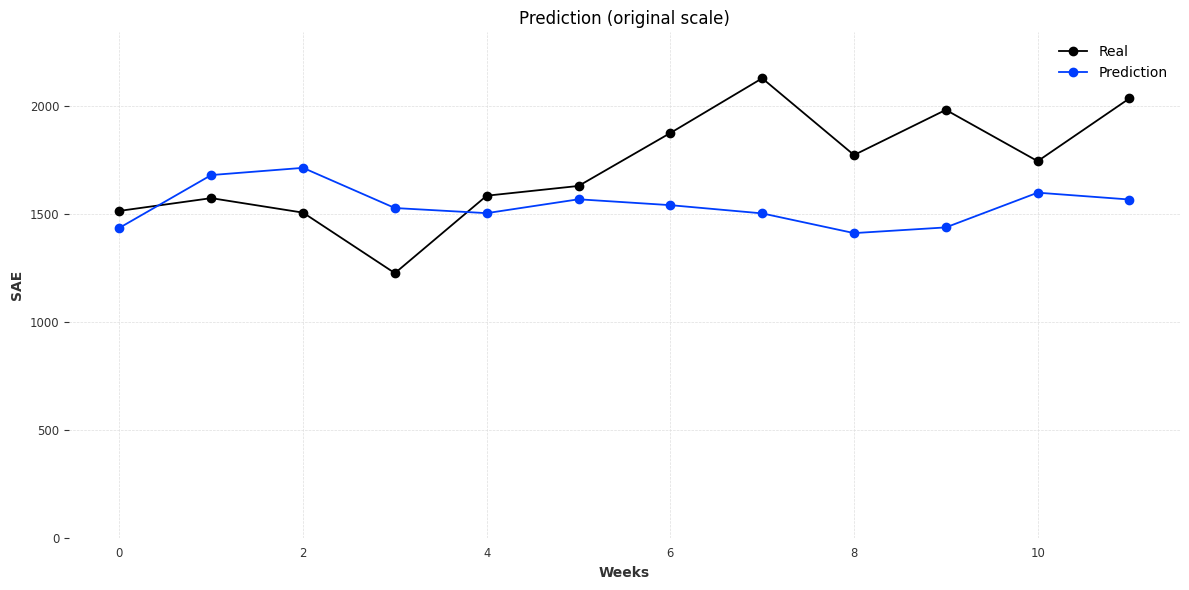

In [2]:
import warnings
import sys
sys.path.append('/Users/zilikons/code/zilikons/jp/shippingNN/')
warnings.filterwarnings("ignore")
import pytorch_lightning as pl
import pandas as pd
import torch
import numpy as np
from datetime import datetime
from functions import error_metrics, run_transformer_xai, get_attention_maps, run_transformer_with_for_xai
from functions import prettify, rename_specific
import os

import matplotlib.pyplot as plt



# torch.set_float32_matmul_precision("high")
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# Configurar dispositivo
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Load data
df = pd.read_csv("../weekly_chile_data.csv")
df["FECHA"] = pd.to_datetime(df["FECHA"])
tmp = df.copy().sort_values("FECHA")

# BEST FE 4
test_size = 4
target_col = "FE"
window_size = 42
batch_size = 128
d_model = 64
n_head = 2
num_layers = 4  # lstm layers
epoch_number = 2000
lr = 0.000340605
dropout = 0.069862972
weight_decay = 0.000187754


#BEST NAE 4

test_size = 4
target_col = "NAE"
window_size = 51
batch_size = 32
d_model = 64
n_head = 4
num_layers = 4  # lstm layers
epoch_number = 2000
lr = 0.000397956
dropout = 0.223329688
weight_decay = 0.000103901

#BEST NAW 4
test_size = 4
target_col = "NAW"
window_size = 41
batch_size = 64
d_model = 128
n_head = 4
num_layers = 4  # lstm layers
epoch_number = 2000
lr = 6.47E-05
dropout = 0.121422183
weight_decay = 6.10E-06



# BEST NE 4
test_size = 4
target_col = "NE"
window_size = 30
batch_size = 128
d_model = 32
n_head = 8
num_layers = 4  # lstm layers
epoch_number = 2000
lr = 9.28E-05
dropout = 0.483863325
weight_decay = 0.000197146

# BEST SE 4
test_size = 4
target_col = "SE"
window_size = 36
batch_size = 32
d_model = 256
n_head = 4
num_layers = 4  # lstm layers
epoch_number = 2000
lr = 0.000555638
dropout = 0.312582405
weight_decay = 0.000179268

# BEST SAW 4
test_size = 4
target_col = "SAW"
window_size = 32
batch_size = 128
d_model = 32
n_head = 2
num_layers = 2  # lstm layers
epoch_number = 2000
lr = 0.000147759
dropout = 0.424560519
weight_decay = 8.66E-05

# BEST SAE 4
test_size = 4
target_col = "SAE"
window_size = 32
batch_size = 32
d_model = 128
n_head = 2
num_layers = 4 # lstm layers
epoch_number = 2000
lr = 0.000482691
dropout = 0.517106545
weight_decay = 7.75E-06



# BEST FE 12
test_size = 12
target_col = "FE"
window_size = 28
batch_size = 32
d_model = 128
n_head = 2
num_layers = 4  # lstm layers
epoch_number = 2000
lr = 0.001
dropout = 0.332641601
weight_decay = 0.001


# BEST NAE 12
test_size = 12
target_col = "NAE"
window_size = 26
batch_size = 32
d_model = 64
n_head = 2
num_layers = 4  # lstm layers
lr = 0.000187546
dropout = 0.273919743
weight_decay = 7.55E-06


# BEST NAW 12
test_size = 12
target_col = "NAW"
window_size = 51
batch_size = 128
d_model = 256
n_head = 8
num_layers = 4  # lstm layers
lr = 0.00029803
dropout = 0.165152428
weight_decay = 5.62E-06


# BEST NE 12
test_size = 12
target_col = "NE"
window_size = 47
batch_size = 32
d_model = 64
n_head = 2
num_layers = 4  # lstm layers
lr = 0.0004815
dropout = 0.318221159
weight_decay = 4.00E-05


#BEST SE 12
test_size = 12
target_col = "SE"
window_size = 50
batch_size = 32
d_model = 64
n_head = 8
num_layers = 4  # lstm layers
lr = 0.000427606
dropout = 0.444859662
weight_decay = 1.50E-05

# BEST SAW 12
test_size = 12
target_col = "SAW"
window_size = 49
batch_size = 128
d_model = 256
n_head = 4
num_layers = 4  # lstm layers
lr = 0.000551659
dropout = 0.426466938
weight_decay = 6.90E-05

# BEST SAE 12
test_size = 12
target_col = "SAE"
window_size = 45
batch_size = 64
d_model = 256
n_head = 8
num_layers = 3  # lstm layers
lr = 0.000496421949598074
dropout = 0.506098106834949
weight_decay = 0.000001

# # BEST SAE 12-26
# test_size = 12
# target_col = "SAE"
# window_size = 9
# batch_size = 32
# d_model = 64
# n_head = 8
# num_layers = 3  # lstm layers
# lr = 0.000919221053433723
# dropout = 0.542695431128164
# weight_decay = 0.0000104850874199825

# # BEST SAE 12-52
# test_size = 12
# target_col = "SAE"
# window_size = 35
# batch_size = 64
# d_model = 64
# n_head = 4
# num_layers = 4  # lstm layers
# lr = 0.000205242989995815
# dropout = 0.329296415109791
# weight_decay = 0.0000716834618189592

#==============================

# General parameters
seed = 42
patience = 200
min_delta = 1e-5
epoch_number = 2000

tmp = df.copy().sort_values("FECHA")
tmp = tmp


avg_mae, avg_mape, avg_mse, avg_rmse, avg_r2, avg_epochs_ran, sd, out, y_true, y_pred = run_transformer_with_for_xai(
    tmp, target_col, window_size, test_size, batch_size, d_model, n_head,
     num_layers, epoch_number, lr, dropout,
     device, seed, optimizer_type='adam', weight_decay=weight_decay, early_stop=True,
     patience=patience,
     min_delta=min_delta,
     n_runs=3,
)

mae, mape, mse, rmse, r2 = error_metrics(y_true, y_pred)

plt.figure(figsize=(12, 6))
plt.plot(y_true, marker="o", label="Real")
plt.plot(y_pred, marker="o", label="Prediction")
plt.title("Prediction (original scale)")
plt.xlabel("Weeks")
plt.ylabel(target_col)
plt.ylim(0, max(max(y_true), max(y_pred)) * 1.1)
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.savefig(f"plots/transformers_prediction_{target_col}_{test_size}.png", dpi=200)

H = test_size  # 4
HORIZON_TO_EXPLAIN = H - 1  # last step (3). Change to 0..3 if you want.

In [30]:
# LIME _____________________________________________-

import numpy as np
from lime.lime_tabular import LimeTabularExplainer
from darts import TimeSeries

model = out[0]
train_ts = out[1]
val_ts = out[2]
scaler_y = out[3]
scaler_cov = out[4]
feature_cols = out[6]

# AUDIT FIX: make sure the model is in inference mode for XAI (dropout OFF)
model.to(device)
model.eval()
torch.set_grad_enabled(False)

# Optional guard: if you truly intend a covariates-only model, the target must NOT be in feature_cols
if target_col in feature_cols:
    print(f"⚠️ WARNING: target_col '{target_col}' is present inside feature_cols. This leaks the target into the model inputs and will invalidate feature importance.")


# Ensure datetime (CRITICAL)
df["FECHA"] = pd.to_datetime(df["FECHA"])

# Rebuild full target series and covariates
full_series = TimeSeries.from_dataframe(df, "FECHA", target_col)
full_cov = TimeSeries.from_dataframe(df, "FECHA", feature_cols)

series_scaled = scaler_y.transform(full_series)
cov_scaled = scaler_cov.transform(full_cov)

F = 1 + len(feature_cols)

# last forecast point
last_idx = len(df) - 1
start_hist = last_idx - test_size + 1 - window_size
assert start_hist >= 0

start_time = df["FECHA"].iloc[start_hist]
end_time = df["FECHA"].iloc[start_hist + window_size - 1]

hist_target = series_scaled.slice(start_time, end_time)
hist_cov = cov_scaled.slice(start_time, end_time)

y_hist_np = hist_target.values(copy=True)
cov_hist_np = hist_cov.values(copy=True)

hist_full_np = np.concatenate([y_hist_np, cov_hist_np], axis=1)
x0 = hist_full_np.flatten()

# Feature names
feat_names = []
cols_all = [target_col] + feature_cols
for t in range(window_size):
    lag = window_size - 1 - t
    for c in cols_all:
        feat_names.append(f"{c}_t-{lag}")

# LIME background
X_lime = np.tile(x0, (200, 1))
X_lime += np.random.normal(scale=0.01, size=X_lime.shape)

explainer = LimeTabularExplainer(
    X_lime,
    feature_names=feat_names,
    mode="regression",
    verbose=False,
    discretize_continuous=False,
)



def _inverse_scale_y(y_scaled: np.ndarray) -> np.ndarray:
    """Inverse-scale a 1D array of scaled forecasts to original scale.
    Supports your custom min-max scaler (vmin/vmax). Falls back to scaler_y.inverse_transform if available.
    """
    y_scaled = np.asarray(y_scaled).reshape(-1)

    # Custom min-max scaler (as used in your code)
    if hasattr(scaler_y, "vmin") and hasattr(scaler_y, "vmax"):
        vmin = np.asarray(scaler_y.vmin).reshape(-1)[0]
        vmax = np.asarray(scaler_y.vmax).reshape(-1)[0]
        return y_scaled * (vmax - vmin) + vmin

    # Fallback: Darts / sklearn-style inverse_transform
    if hasattr(scaler_y, "inverse_transform"):
        try:
            from darts import TimeSeries
            ts = TimeSeries.from_values(y_scaled.reshape(-1, 1))
            inv = scaler_y.inverse_transform(ts).values(copy=False).reshape(-1)
            return inv
        except Exception as e:
            raise RuntimeError(f"Could not inverse_transform with scaler_y: {e}") from e

    raise RuntimeError("Unknown scaler_y type: cannot inverse-scale predictions.")


def predict_fn(flat_X):
    """LIME predict_fn: returns a 1D array of predictions for the selected horizon."""
    assert 0 <= HORIZON_TO_EXPLAIN < H, f"HORIZON_TO_EXPLAIN={HORIZON_TO_EXPLAIN} out of range [0,{H-1}]"

    flat_X = np.asarray(flat_X)
    preds = np.zeros(flat_X.shape[0], dtype=float)

    for i in range(flat_X.shape[0]):
        arr = flat_X[i].reshape(window_size, F)

        # Transformer ONLY uses covariates (match your training pipeline)
        cov_win = arr[:, 1:]  # (T, n_cov)

        X = torch.tensor(cov_win, dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            y_hat_scaled = model(X).detach().cpu().numpy().reshape(-1)  # (H,)

        y_hat = _inverse_scale_y(y_hat_scaled)
        preds[i] = float(np.asarray(y_hat[HORIZON_TO_EXPLAIN]).squeeze())

    return preds

Top mean LIME contributions:
Csi300 Volume T-0             0.709395
Freight Per TEU T-0           0.595669
Clp Price T-0                 0.517792
Brent Oil Price T-0           0.468089
Yang Ming Volume T-0          0.424810
South America West T-0        0.328330
Total TEU Vietnam T-0         0.265736
North America East T-0        0.211713
Total TEU Belgica T-0         0.202502
Total TEU Maersk T-0          0.194809
Total TEU Cma Cgm T-0         0.177376
Time Idx T-0                  0.165083
FE T-2                        0.086780
NGF Natural Gas Volume T-0    0.067975
Total TEU Francia T-0        -0.143353
dtype: float64

Top unstable features (std):
csi300_volume_t-0             NaN
FLETE_per_TEU_t-0             NaN
SUM_TEU_SIN CLAUSULA_t-0      NaN
clp_price_t-0                 NaN
brent_oil_price_t-0           NaN
SUM_TEU_other_companies_t-0   NaN
yang_ming_volume_t-0          NaN
CANTIDAD DE BULTO_t-0         NaN
SAW_t-0                       NaN
hapag_volume_t-0              NaN
S

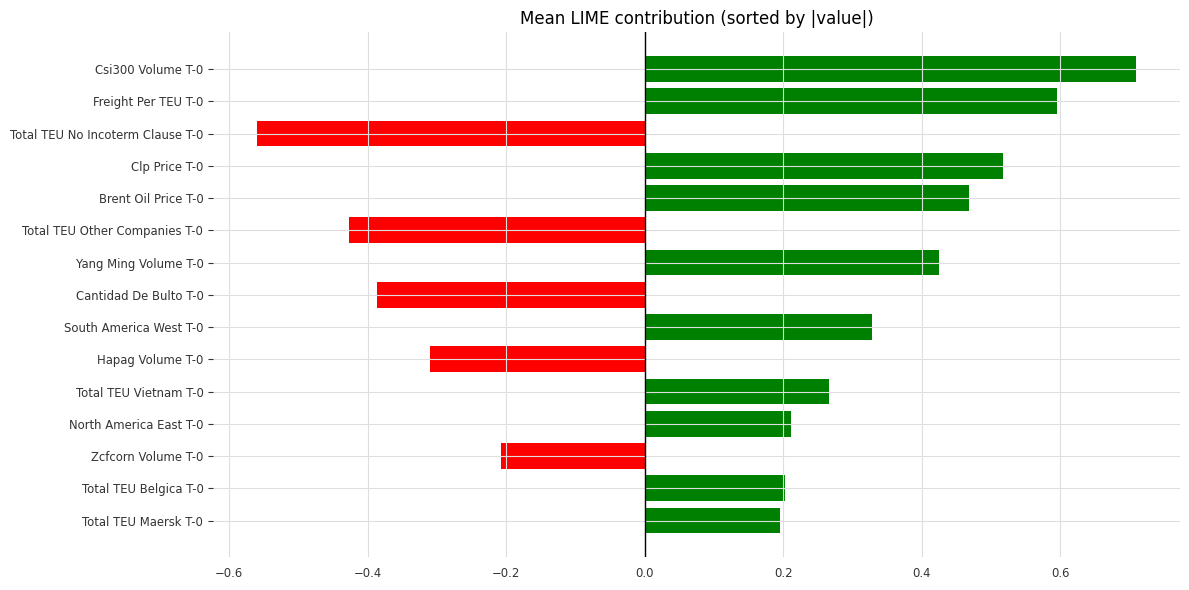

In [31]:
# ------------------------------------------------------------
# LIME stability analysis for ONE prediction (x0)
# ------------------------------------------------------------
#
# This LIME averages multiple runs to improve stability, while vanilla LIME uses a single random explanation.

# This Lime also disables discretaization to improve stability (because of the gaussian perturbations).

#flatten time series window



N = 1  # number of LIME runs to average
weights = []

for s in range(N):
    np.random.seed(1000 + s)
    exp = explainer.explain_instance(
        x0,
        predict_fn,
        num_features=20
    )
    weights.append(dict(exp.as_list()))

df_local_lime = pd.DataFrame(weights).fillna(0)

mean_importance = df_local_lime.mean().sort_values(ascending=False)
mean_importance.index = rename_specific(
    [prettify(n) for n in mean_importance.index]
)
std_importance = df_local_lime.std().sort_values(ascending=False)

print("Top mean LIME contributions:")
print(mean_importance.head(15))

print("\nTop unstable features (std):")
print(std_importance.head(15))

top_pos = mean_importance.sort_values(ascending=False).head(8)
top_neg = mean_importance.sort_values().head(8)

vals = mean_importance.copy()

# sort by absolute contribution
vals = vals.reindex(vals.abs().sort_values(ascending=False).index)

# keep top-k
vals = vals.head(15)
vals.index = rename_specific([prettify(n) for n in vals.index])
colors = ["green" if v > 0 else "red" for v in vals]

plt.figure(figsize=(12, 6))
plt.barh(vals.index, vals.values, color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.gca().invert_yaxis()
plt.title("Mean LIME contribution (sorted by |value|)")
plt.tight_layout()
# plt.savefig(
#     f"plots/local_lime_mean_abs_{target_col}_{test_size}.png",
#     dpi=200,
#     bbox_inches="tight"
# )
plt.show()


X_explain shape: (12, 3600)

Explaining origin 1/12 (end_idx=420)...

Explaining origin 2/12 (end_idx=421)...

Explaining origin 3/12 (end_idx=422)...

Explaining origin 4/12 (end_idx=423)...

Explaining origin 5/12 (end_idx=424)...

Explaining origin 6/12 (end_idx=425)...

Explaining origin 7/12 (end_idx=426)...

Explaining origin 8/12 (end_idx=427)...

Explaining origin 9/12 (end_idx=428)...

Explaining origin 10/12 (end_idx=429)...

Explaining origin 11/12 (end_idx=430)...

Explaining origin 12/12 (end_idx=431)...

Mean LIME surrogate fidelity (R^2) across runs: 0.9941022074183898

Top 30 flat features:
                             feature  importance_abs     signed  \
3579                    clp_price_t0       39.851732  39.851732   
3582                csi300_volume_t0       39.096248  38.845923   
3580                    cny_price_t0       35.081369 -35.081369   
3577              brent_oil_price_t0       31.961869  31.961869   
3542              SUM_TEU_ECUADOR_t0       20.87053

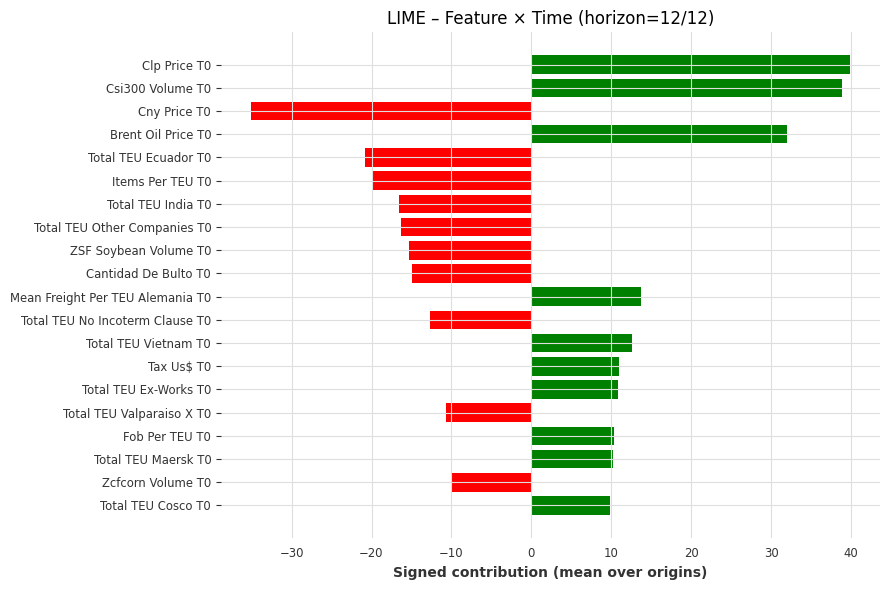

In [8]:
# ============================================================
# BUILD VALID WINDOWS + GLOBAL / AGGREGATED LIME (FIXED)
# ============================================================
#
# Key fixes vs original:
#   1) Uses VALID forecast origins only (no future leakage): end <= N_total - H - 1
#   2) Uses a LARGE background (X_bg) for stable feature statistics (std != ~0)
#   3) Forces LOCAL sampling around each instance (sample_around_instance=True)
#   4) Converts LIME coefficients -> per-instance contributions (coef * x_scaled)
#      so "signed" really means push up/down relative to the background mean.

from lime.lime_tabular import LimeTabularExplainer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0) Build MANY valid windows (no peeking into the future)
# ------------------------------------------------------------
cols_all = [target_col] + feature_cols
F = len(cols_all)
T = window_size
H = test_size

# Work directly in numpy (avoids any TimeSeries slicing surprises)
y_all = series_scaled.values(copy=True)   # (N_total, 1)
cov_all = cov_scaled.values(copy=True)    # (N_total, n_cov)
N_total = len(y_all)

end_min = T - 1
end_max = N_total - H - 1  # last origin with full H-step future available
assert end_max >= end_min, (
    f"Not enough data: need at least window_size={T} + horizon={H} points."
)

valid_ends = np.arange(end_min, end_max + 1)

# ------------------------------------------------------------
# 1) Windows to explain (keep your original intent: last H origins)
#    IMPORTANT: these are origins; the explained target time is end + HORIZON_TO_EXPLAIN + 1
# ------------------------------------------------------------
N_ORIGINS = min(test_size, len(valid_ends))  # you can increase this (e.g., 50-200) for smoother globals
ends_explain = valid_ends[-N_ORIGINS:]

X_explain = np.zeros((N_ORIGINS, T * F), dtype=float)
for i, end in enumerate(ends_explain):
    start = end - T + 1
    X_explain[i] = np.concatenate(
        [y_all[start:end + 1], cov_all[start:end + 1]],
        axis=1
    ).reshape(-1)

print("X_explain shape:", X_explain.shape)

# ------------------------------------------------------------
# 2) Background for LIME statistics (MUCH larger than N_ORIGINS)
# ------------------------------------------------------------
N_BACKGROUND = min(500, len(valid_ends))
rng = np.random.default_rng(seed)
bg_ends = rng.choice(valid_ends, size=N_BACKGROUND, replace=False)

X_bg = np.zeros((N_BACKGROUND, T * F), dtype=float)
for i, end in enumerate(bg_ends):
    start = end - T + 1
    X_bg[i] = np.concatenate(
        [y_all[start:end + 1], cov_all[start:end + 1]],
        axis=1
    ).reshape(-1)

# ------------------------------------------------------------
# 3) Feature names (must match flattening order!)
# ------------------------------------------------------------
feature_names = [
    f"{cols_all[j]}_t{T - 1 - t}"
    for t in range(T)
    for j in range(F)
]
feat_to_idx = {name: k for k, name in enumerate(feature_names)}
n_features = len(feature_names)

# ------------------------------------------------------------
# 4) LIME explainer
# ------------------------------------------------------------
explainer = LimeTabularExplainer(
    X_bg,
    feature_names=feature_names,
    mode="regression",
    verbose=False,
    discretize_continuous=False,
    sample_around_instance=True,  # <<< CRITICAL for "local" explanations with a global background
    random_state=seed,
)

# ------------------------------------------------------------
# 5) Aggregate LIME over origins (and repeats for stability)
# ------------------------------------------------------------
N_REPEATS = 10
NUM_SAMPLES = 5000  # explicit (LIME default), increase for more stability

agg_signed = np.zeros(n_features, dtype=float)
agg_abs = np.zeros(n_features, dtype=float)
scores = []

for i in range(N_ORIGINS):
    print(f"\nExplaining origin {i + 1}/{N_ORIGINS} (end_idx={int(ends_explain[i])})...")

    # scaled instance values used by LIME's surrogate model (when discretize_continuous=False)
    x_scaled = explainer.scaler.transform(X_explain[i].reshape(1, -1))[0]

    contrib_runs = []

    for s in range(N_REPEATS):
        # vary seed across both origin and repeat
        np.random.seed(1000 + i * 100 + s)

        exp_i = explainer.explain_instance(
            X_explain[i],
            predict_fn,
            num_features=n_features,
            num_samples=NUM_SAMPLES,
        )

        scores.append(getattr(exp_i, "score", np.nan))

        # exp_i.as_list() returns coefficients of the local linear surrogate
        coef_vec = np.zeros(n_features, dtype=float)
        for feat_name, w in exp_i.as_list():
            coef_vec[feat_to_idx[feat_name]] = w

        # Convert coefficients -> per-feature contribution at this instance:
        # contribution_j = coef_j * x_scaled_j
        contrib_runs.append(coef_vec * x_scaled)

    contrib_mean = np.mean(contrib_runs, axis=0)

    agg_signed += contrib_mean
    agg_abs += np.abs(contrib_mean)

agg_signed /= N_ORIGINS
agg_abs /= N_ORIGINS

print("\nMean LIME surrogate fidelity (R^2) across runs:", float(np.nanmean(scores)))

lime_summary = pd.DataFrame({
    "feature": feature_names,
    "importance_abs": agg_abs,
    "signed": agg_signed,
})
lime_summary["importance_pos"] = np.clip(lime_summary["signed"], 0, None)
lime_summary["importance_neg"] = np.clip(lime_summary["signed"], None, 0)

lime_summary = lime_summary.sort_values("importance_abs", ascending=False)

print("\nTop 30 flat features:")
print(lime_summary.head(30))

lime_summary["feature_pretty"] = rename_specific(
    [prettify(f) for f in lime_summary["feature"]]
)

# ------------------------------------------------------------
# 6) Plot: feature × time
# ------------------------------------------------------------
top = lime_summary.head(20)
colors = ["green" if v >= 0 else "red" for v in top["signed"]]

plt.figure(figsize=(9, 6))
plt.barh(top["feature_pretty"], top["signed"], color=colors)
plt.gca().invert_yaxis()
plt.xlabel("Signed contribution (mean over origins)")
plt.title(f"LIME – Feature × Time (horizon={HORIZON_TO_EXPLAIN + 1}/{H})")
plt.tight_layout()

plt.savefig(
    f"plots/lime_feature_time_{target_col}_H{test_size}.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


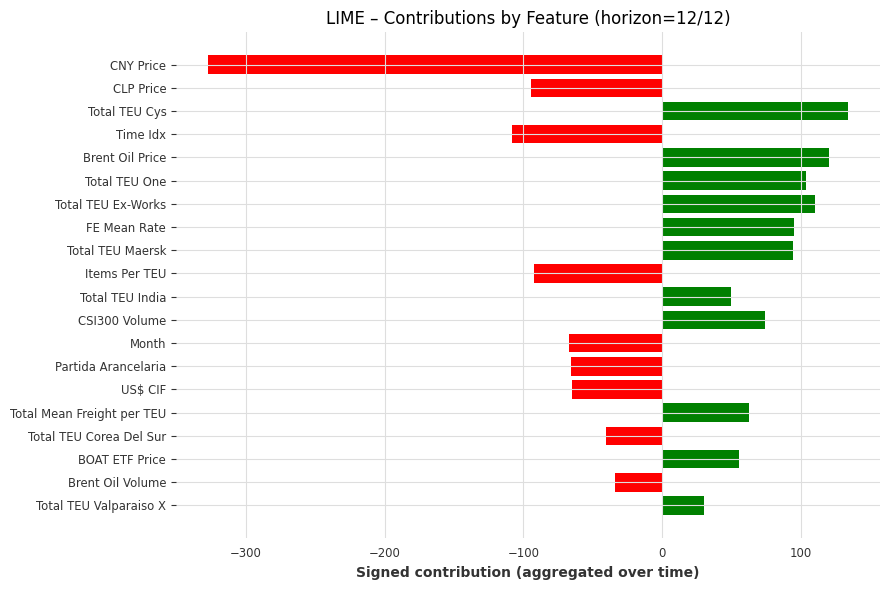

In [9]:
# ------------------------------------------------------------
# 7) Aggregate over TIME → base feature
# ------------------------------------------------------------
lime_summary["base_feature"] = (
    lime_summary["feature"].str.rsplit("_t", n=1).str[0]
)

agg_feat = (
    lime_summary
    .groupby("base_feature", as_index=False)
    .agg(
        signed=("signed", "sum"),
        importance_abs=("importance_abs", "sum"),
    )
    .sort_values("importance_abs", ascending=False)
)

agg_feat["base_feature_pretty"] = rename_specific(
    [prettify(f) for f in agg_feat["base_feature"]]
)
topf = agg_feat.head(20)
colors = ["green" if v >= 0 else "red" for v in topf["signed"]]

plt.figure(figsize=(9, 6))
plt.barh(topf["base_feature_pretty"], topf["signed"], color=colors)
plt.gca().invert_yaxis()
plt.xlabel("Signed contribution (aggregated over time)")
plt.title(f"LIME – Contributions by Feature (horizon={HORIZON_TO_EXPLAIN + 1}/{H})")
plt.tight_layout()

plt.savefig(
    f"plots/lime_feature_agg_{target_col}_H{test_size}.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


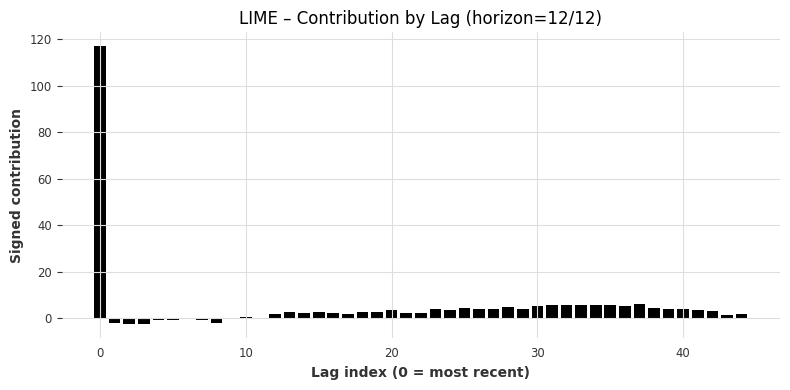

In [10]:
# ------------------------------------------------------------
# 8) Aggregate by TIME STEP (lag)
# ------------------------------------------------------------
lime_summary["time"] = (
    lime_summary["feature"]
    .str.extract(r"_t(\d+)$")
    .astype(int)
)

time_agg = (
    lime_summary
    .groupby("time", as_index=False)
    .agg(
        signed=("signed", "sum"),
        importance_abs=("importance_abs", "sum"),
    )
    .sort_values("time")
)

plt.figure(figsize=(8, 4))
plt.bar(time_agg["time"], time_agg["signed"])
plt.xlabel("Lag index (0 = most recent)")
plt.ylabel("Signed contribution")
plt.title(f"LIME – Contribution by Lag (horizon={HORIZON_TO_EXPLAIN + 1}/{H})")
plt.tight_layout()

plt.savefig(
    f"plots/lime_lag_contribution_{target_col}_H{test_size}.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

Initializing DeepSHAP with 100 background samples...
Explaining 12 instances for horizon 12/12
DeepExplainer initialized successfully!

Computing SHAP values...
SHAP values shape (raw): (12, 45, 79, 1)
SHAP values shape (squeezed): (12, 45, 79)

Top 30 features by DeepSHAP:
                                    feature  importance_abs    signed
3535                          cny_price_t-0        0.006868 -0.006868
3537                      csi300_volume_t-0        0.006144  0.004627
3534                          clp_price_t-0        0.005579  0.005579
3486                      FLETE_per_TEU_t-0        0.003968 -0.003968
3521               SUM_TEU_SIN CLAUSULA_t-0        0.003545  0.000257
3554                              month_t-0        0.003471  0.003471
3552                  zsfsoybean_volume_t-0        0.003138 -0.001969
3489                      ITEMS PER TEU_t-0        0.003014 -0.003014
3517         MEAN_FLETE_per_TEU_HAMBURG_t-0        0.002987 -0.001980
3509        MEAN_FLETE_pe

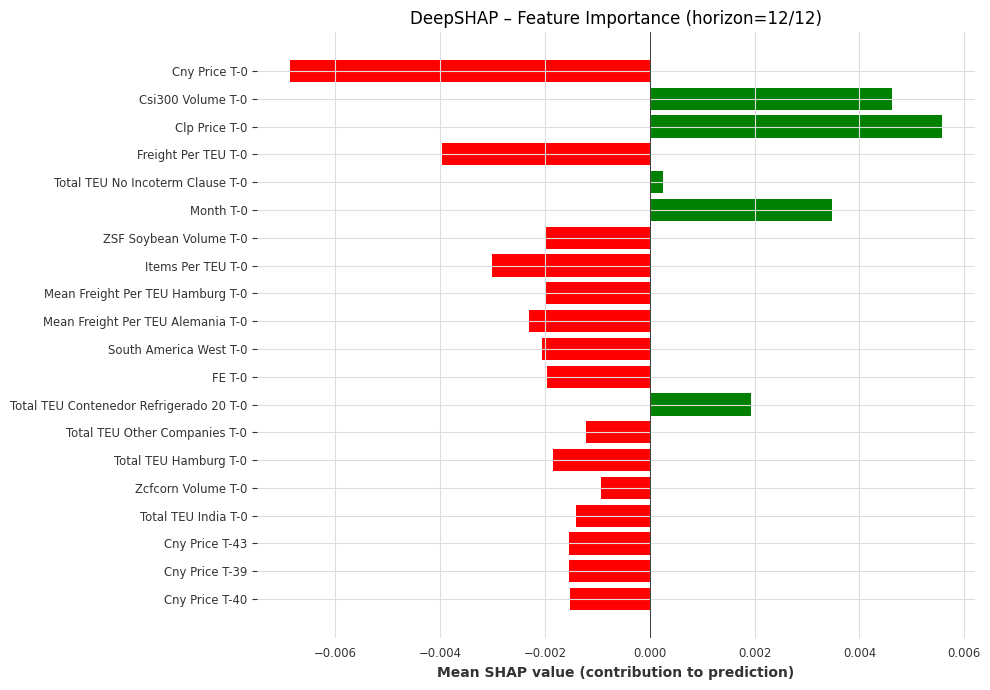

In [32]:
# ============================================================
# DEEP SHAP FOR TRANSFORMER MODEL
# ============================================================
#
# DeepSHAP uses the DeepLIFT algorithm to compute SHAP values efficiently
# for deep neural networks. It provides theoretically grounded feature
# attributions based on Shapley values.

import shap
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functions import prettify, rename_specific

# ------------------------------------------------------------
# 0) Setup: Extract model and data from your training output
# ------------------------------------------------------------
xai_device = torch.device("cpu")
model = out[0]
train_ts = out[1]
val_ts = out[2]
scaler_y = out[3]
scaler_cov = out[4]
feature_cols = out[6]

torch.set_grad_enabled(True)
# Ensure model is in eval mode
model.to(xai_device)
model.eval()

# Rebuild scaled series (same as your LIME code)
df["FECHA"] = pd.to_datetime(df["FECHA"])
full_series = TimeSeries.from_dataframe(df, "FECHA", target_col)
full_cov = TimeSeries.from_dataframe(df, "FECHA", feature_cols)
series_scaled = scaler_y.transform(full_series)
cov_scaled = scaler_cov.transform(full_cov)

# ------------------------------------------------------------
# 1) Build valid windows (same logic as your LIME code)
# ------------------------------------------------------------
cols_all = [target_col] + feature_cols
F = len(cols_all)
T = window_size
H = test_size

y_all = series_scaled.values(copy=True)   # (N_total, 1)
cov_all = cov_scaled.values(copy=True)    # (N_total, n_cov)
N_total = len(y_all)

end_min = T - 1
end_max = N_total - H - 1
valid_ends = np.arange(end_min, end_max + 1)

# ------------------------------------------------------------
# 2) Create background dataset for SHAP
# ------------------------------------------------------------
N_BACKGROUND = min(100, len(valid_ends))  # DeepSHAP works well with ~100 background samples
rng = np.random.default_rng(seed)
bg_ends = rng.choice(valid_ends, size=N_BACKGROUND, replace=False)

# For DeepSHAP, we need the INPUT format the model expects
# Your transformer uses only covariates (not target), shape: (batch, T, n_cov)
n_cov = len(feature_cols)

X_background = np.zeros((N_BACKGROUND, T, n_cov), dtype=np.float32)
for i, end in enumerate(bg_ends):
    start = end - T + 1
    X_background[i] = cov_all[start:end + 1]

X_background_tensor = torch.tensor(X_background, dtype=torch.float32).to(xai_device)

# ------------------------------------------------------------
# 3) Create instances to explain (last N origins)
# ------------------------------------------------------------
N_EXPLAIN = min(test_size, len(valid_ends))
ends_explain = valid_ends[-N_EXPLAIN:]

X_explain = np.zeros((N_EXPLAIN, T, n_cov), dtype=np.float32)
for i, end in enumerate(ends_explain):
    start = end - T + 1
    X_explain[i] = cov_all[start:end + 1]

X_explain_tensor = torch.tensor(X_explain, dtype=torch.float32).to(xai_device)

# ------------------------------------------------------------
# 4) Wrapper model for SHAP (to select specific horizon output)
# ------------------------------------------------------------
class ModelWrapperForHorizon(torch.nn.Module):
    """Wraps the transformer to output only the selected forecast horizon."""
    def __init__(self, model, horizon_idx):
        super().__init__()
        self.model = model
        self.horizon_idx = horizon_idx

    def forward(self, x):
        # model output shape: (batch, H) or (batch, H, 1)
        out = self.model(x)
        if out.dim() == 3:
            out = out.squeeze(-1)  # (batch, H)
        return out[:, self.horizon_idx:self.horizon_idx+1]  # (batch, 1)

wrapped_model = ModelWrapperForHorizon(model, HORIZON_TO_EXPLAIN)
wrapped_model.eval()

# ------------------------------------------------------------
# 5) Initialize DeepSHAP explainer
# ------------------------------------------------------------
print(f"Initializing DeepSHAP with {N_BACKGROUND} background samples...")
print(f"Explaining {N_EXPLAIN} instances for horizon {HORIZON_TO_EXPLAIN + 1}/{H}")

# DeepExplainer for deep neural networks
try:
    explainer_shap = shap.DeepExplainer(wrapped_model, X_background_tensor)
    print("DeepExplainer initialized successfully!")
except Exception as e:
    print(f"DeepExplainer failed: {e}")
    print("Falling back to GradientExplainer...")
    explainer_shap = shap.GradientExplainer(wrapped_model, X_background_tensor)

# ------------------------------------------------------------
# 6) Compute SHAP values
# ------------------------------------------------------------
print("\nComputing SHAP values...")
shap_values = explainer_shap.shap_values(X_explain_tensor, check_additivity=False)

# Handle output format
if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.array(shap_values)
print(f"SHAP values shape (raw): {shap_values.shape}")

# FIX: Squeeze any extra dimensions (e.g., output dimension)
shap_values = np.squeeze(shap_values)
print(f"SHAP values shape (squeezed): {shap_values.shape}")

# Ensure shape is (N_EXPLAIN, T, n_cov)
if shap_values.ndim == 2:
    # If flattened, reshape
    shap_values = shap_values.reshape(N_EXPLAIN, T, n_cov)

# ------------------------------------------------------------
# 7) Aggregate SHAP values across instances
# ------------------------------------------------------------
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)  # (T, n_cov)
mean_signed_shap = np.mean(shap_values, axis=0)       # (T, n_cov)

shap_feature_names = []
shap_abs_values = []
shap_signed_values = []

for t in range(T):
    lag = T - 1 - t
    for j, col in enumerate(feature_cols):
        shap_feature_names.append(f"{col}_t-{lag}")
        # FIX: Ensure scalar values
        shap_abs_values.append(float(mean_abs_shap[t, j]))
        shap_signed_values.append(float(mean_signed_shap[t, j]))

shap_summary = pd.DataFrame({
    "feature": shap_feature_names,
    "importance_abs": shap_abs_values,
    "signed": shap_signed_values,
})
shap_summary = shap_summary.sort_values("importance_abs", ascending=False)

print("\nTop 30 features by DeepSHAP:")
print(shap_summary.head(30))

# ------------------------------------------------------------
# 8) Plot: Top features by signed importance
# ------------------------------------------------------------
top_shap = shap_summary.head(20).copy()
top_shap["feature_pretty"] = rename_specific(
    [prettify(f) for f in top_shap["feature"]]
)

# FIX: Ensure values are plain floats for plotting
signed_values = top_shap["signed"].astype(float).tolist()
colors = ["green" if v >= 0 else "red" for v in signed_values]

plt.figure(figsize=(10, 7))
plt.barh(top_shap["feature_pretty"].tolist(), signed_values, color=colors)
plt.gca().invert_yaxis()
plt.xlabel("Mean SHAP value (contribution to prediction)")
plt.title(f"DeepSHAP – Feature Importance (horizon={HORIZON_TO_EXPLAIN + 1}/{H})")
plt.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.savefig(
    f"plots/deepshap_feature_importance_{target_col}_H{test_size}.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

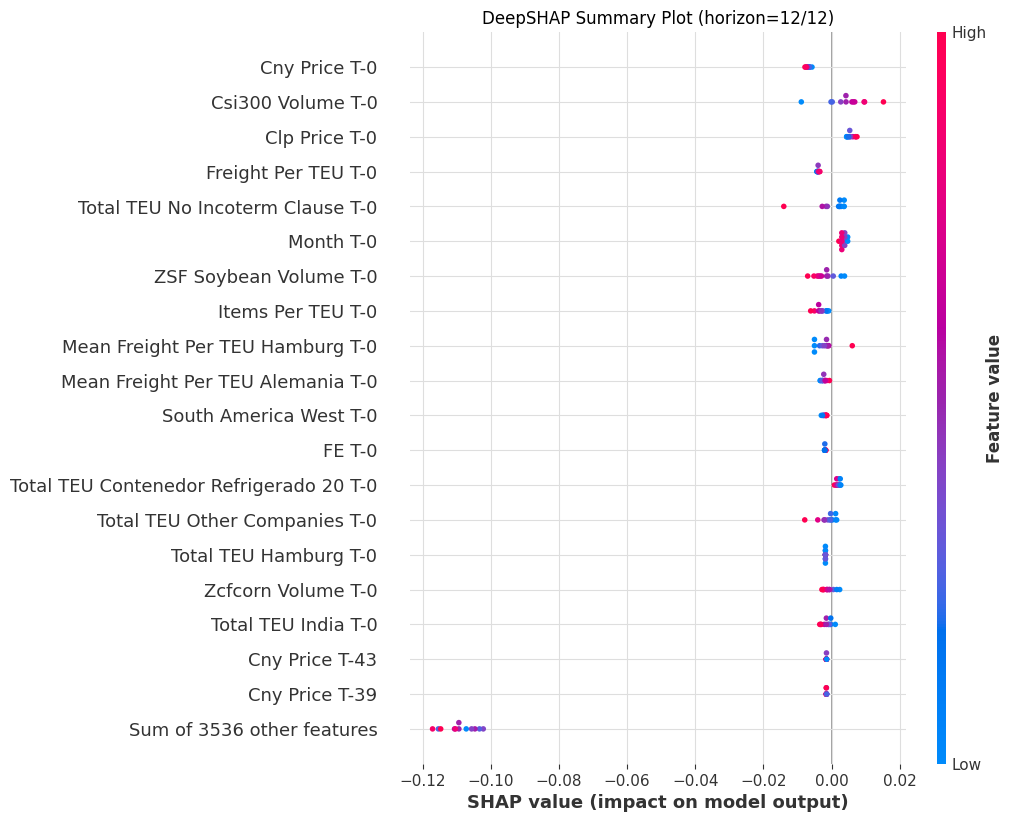

In [33]:

# ------------------------------------------------------------
# 9) SHAP Summary Plot (beeswarm style)
# ------------------------------------------------------------
# Reshape for SHAP's built-in plotting
shap_flat = shap_values.reshape(N_EXPLAIN, -1)  # (N_EXPLAIN, T * n_cov)
X_flat = X_explain.reshape(N_EXPLAIN, -1)       # (N_EXPLAIN, T * n_cov)

# Create feature names for flattened data
flat_feature_names = []
for t in range(T):
    lag = T - 1 - t
    for col in feature_cols:
        flat_feature_names.append(f"{col}_t-{lag}")

# Pretty names
flat_feature_names_pretty = rename_specific(
    [prettify(f) for f in flat_feature_names]
)

# Create SHAP Explanation object for built-in plots
explanation = shap.Explanation(
    values=shap_flat,
    base_values=np.zeros(N_EXPLAIN),  # DeepSHAP normalizes around 0
    data=X_flat,
    feature_names=flat_feature_names_pretty
)

plt.figure(figsize=(12, 8))
shap.plots.beeswarm(explanation, max_display=20, show=False)
plt.title(f"DeepSHAP Summary Plot (horizon={HORIZON_TO_EXPLAIN + 1}/{H})")
plt.savefig(
    f"plots/deepshap_beeswarm_{target_col}_H{test_size}.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


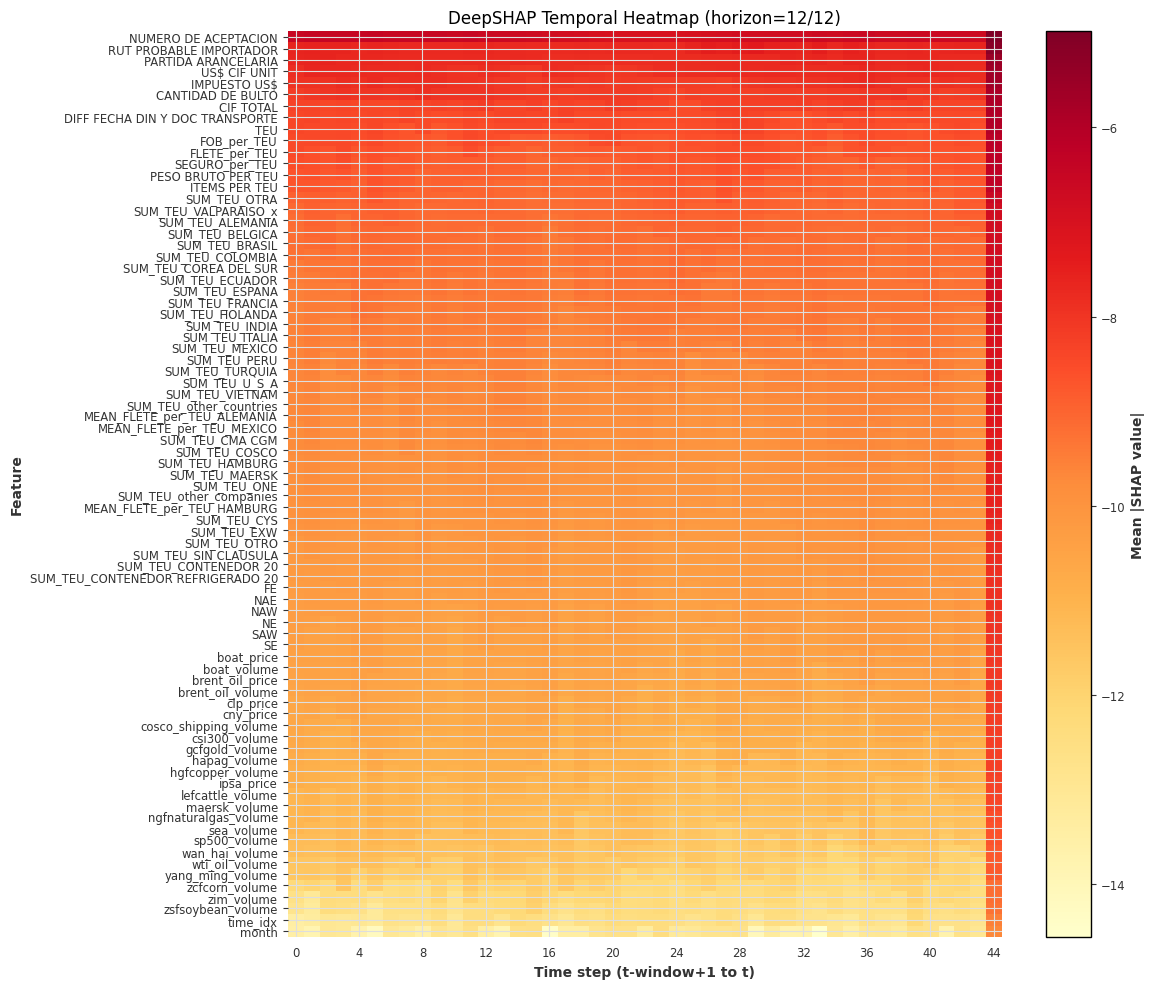

In [38]:

# ------------------------------------------------------------
# 10) Temporal importance heatmap (Feature × Time)
# ------------------------------------------------------------
# Sum absolute SHAP across all instances
temporal_importance = np.mean(np.log(np.abs(shap_values) + 1e-8), axis=0).T  # (n_cov, T)
temporal_importance = np.sort(temporal_importance, axis=0)[::-1]  # sort features by importance
plt.figure(figsize=(12, 10))
plt.imshow(temporal_importance, aspect='auto', cmap='YlOrRd')
plt.colorbar(label='Mean |SHAP value|')
plt.xlabel('Time step (t-window+1 to t)')
plt.ylabel('Feature')
plt.yticks(range(n_cov), feature_cols)
plt.xticks(range(0, T, max(1, T//10)), range(0, T, max(1, T//10)))
plt.title(f"DeepSHAP Temporal Heatmap (horizon={HORIZON_TO_EXPLAIN + 1}/{H})")
plt.tight_layout()
plt.savefig(
    f"plots/deepshap_temporal_heatmap_{target_col}_H{test_size}.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


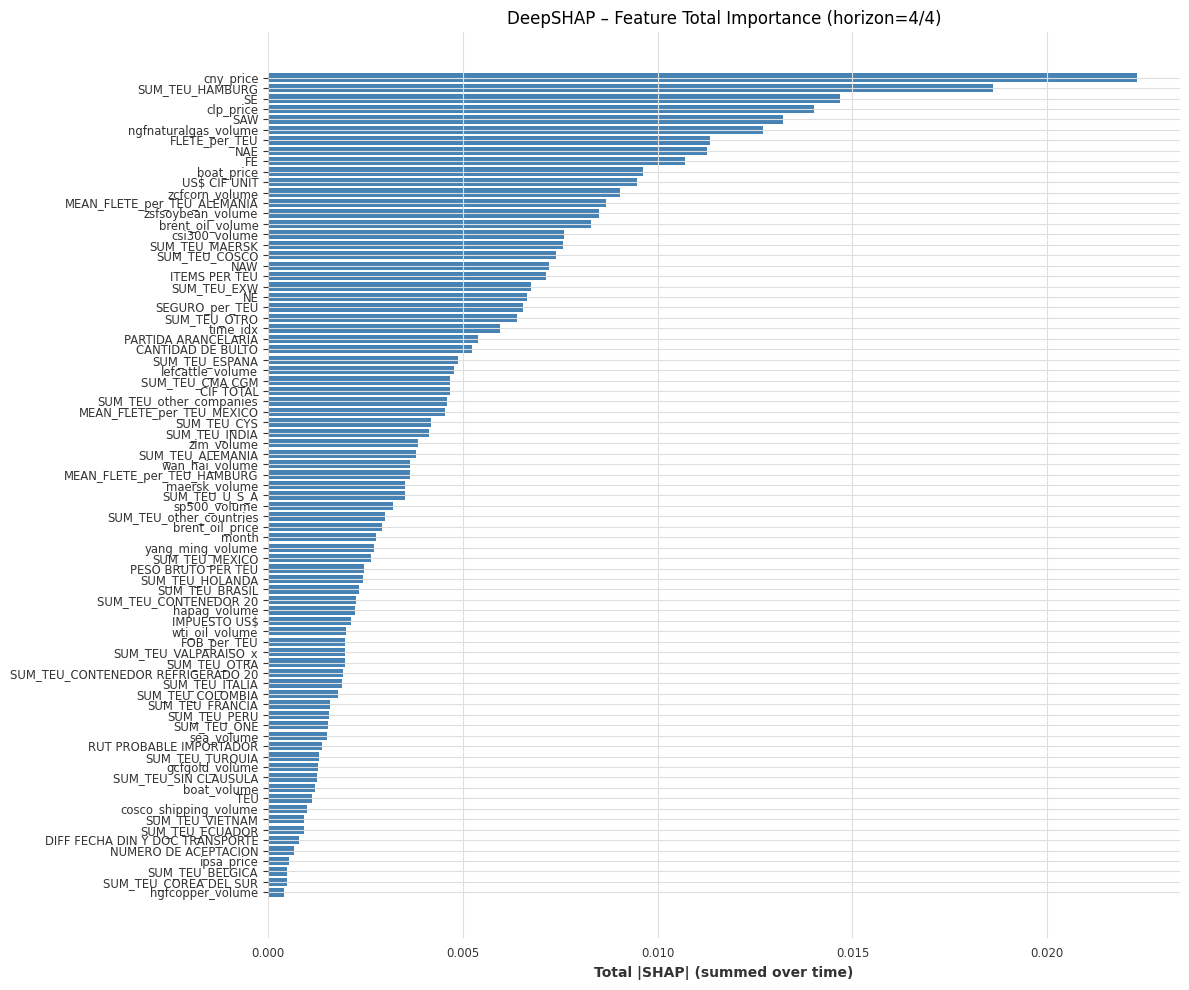


DeepSHAP analysis complete!


In [28]:

# ------------------------------------------------------------
# 11) Per-feature total importance (summed over time)
# ------------------------------------------------------------
feature_total_importance = np.sum(np.abs(mean_abs_shap), axis=0)  # (n_cov,)
feature_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "total_importance": feature_total_importance
}).sort_values("total_importance", ascending=True)

plt.figure(figsize=(12, 10))
plt.barh(feature_importance_df["feature"], feature_importance_df["total_importance"], color="steelblue")
plt.xlabel("Total |SHAP| (summed over time)")
plt.title(f"DeepSHAP – Feature Total Importance (horizon={HORIZON_TO_EXPLAIN + 1}/{H})")
plt.tight_layout()
plt.savefig(
    f"plots/deepshap_feature_total_{target_col}_H{test_size}.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

print("\n" + "="*60)
print("DeepSHAP analysis complete!")
print("="*60)

In [ ]:
#SHAPLEY

# ______________
groups = {}
for j, name in enumerate(feat_names):
    base = name.rsplit("_t", 1)[0]
    groups.setdefault(base, []).append(j)

group_names = list(groups.keys())

import numpy as np


def permutation_shapley(
        predict_fn,
        x0,
        background,
        groups,
        n_perm=200
):
    group_names = list(groups.keys())
    M = len(group_names)
    phi = np.zeros(M)

    base_pred = predict_fn(background.reshape(1, -1))[0]

    for _ in range(n_perm):
        perm = np.random.permutation(M)
        x_curr = background.copy()
        prev = base_pred

        for idx in perm:
            g = group_names[idx]
            x_curr[groups[g]] = x0[groups[g]]
            val = predict_fn(x_curr.reshape(1, -1))[0]
            phi[idx] += val - prev
            prev = val

    return phi / n_perm, group_names


baseline = (X_bg.mean(axis=0) if 'X_bg' in globals() else X_lime.mean(axis=0))
phi, group_names = permutation_shapley(
    predict_fn,
    x0,
    baseline,
    groups,
    n_perm=300
)

import shap

shap_exp = shap.Explanation(
    values=phi,
    base_values=predict_fn(baseline.reshape(1, -1))[0],
    data=None,
    feature_names=rename_specific([prettify(n) for n in group_names])
)

shap.plots.waterfall(shap_exp, max_display=12, show=False)
plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
plt.savefig(
    f"plots/shap_waterfall_{target_col}_{test_size}.png",
    dpi=200,
    bbox_inches="tight"
)
plt.close()





import numpy as np
import shap
import matplotlib.pyplot as plt

# -------------------------
# 0) Dimensions and baseline
# -------------------------
T = window_size
F = 1 + len(feature_cols)  # target + covs
H = test_size  # forecast horizon
D = T * F

x0 = np.asarray(x0).reshape(-1)
assert x0.shape[0] == D, f"x0 must be length {D}, got {x0.shape[0]}"

# baseline window (mean of background)
baseline = (X_bg.mean(axis=0) if 'X_bg' in globals() else X_lime.mean(axis=0)).copy()
baseline = np.asarray(baseline).reshape(-1)
assert baseline.shape[0] == D

# -----------------------------------------
# 1) Build GROUPS (by base feature, across lags)
# -----------------------------------------
# feat_names are like "<col>_t-<lag>" or "<col>_t<lag>"
groups = {}
for j, name in enumerate(feat_names):
    base = name.rsplit("_t", 1)[0]
    groups.setdefault(base, []).append(j)

group_names = list(groups.keys())
M = len(group_names)
print("Num groups:", M)


# -----------------------------------------
# 2) Transformer multi-horizon predictor
# -----------------------------------------
def predict_all_horizons(flat_X):
    """
    flat_X: (n_samples, D)
    returns: (n_samples, H) in ORIGINAL scale
    """
    flat_X = np.asarray(flat_X)
    n = flat_X.shape[0]
    outs = np.zeros((n, H), dtype=float)

    for i in range(n):
        arr = flat_X[i].reshape(T, F)

        # Transformer input: covariates only (match your training)
        cov_win = arr[:, 1:]  # (T, n_cov)
        X = torch.tensor(cov_win, dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            y_hat_scaled = model(X).cpu().numpy().reshape(-1)  # (H,)

        # inverse-scale all horizons
        y_hat = y_hat_scaled * (scaler_y.vmax - scaler_y.vmin) + scaler_y.vmin
        outs[i, :] = y_hat

    return outs


def predict_horizon(h, x_flat):
    """
    h in [0..H-1], x_flat: (D,)
    returns scalar forecast at horizon h (original scale)
    """
    return predict_all_horizons(x_flat.reshape(1, -1))[0, h]


# -----------------------------------------
# 3) Vanilla permutation Shapley for one horizon
# -----------------------------------------
def permutation_shapley_single_h(predict_h, x0, baseline, groups, group_names, n_perm=200):
    phi = np.zeros(len(group_names), dtype=float)

    f_base = predict_h(baseline)

    for _ in range(n_perm):
        perm = np.random.permutation(len(group_names))
        x_curr = baseline.copy()
        prev = f_base

        for k in perm:
            g = group_names[k]
            x_curr[groups[g]] = x0[groups[g]]
            val = predict_h(x_curr)
            phi[k] += val - prev
            prev = val

    return phi / n_perm


# -----------------------------------------
# 4) Compute Shapley per horizon, then aggregate (Option 1)
# -----------------------------------------
n_perm = 300  # increase if you want more stability
phi_horizons = np.zeros((H, M), dtype=float)

for h in range(H):
    phi_horizons[h, :] = permutation_shapley_single_h(
        predict_h=lambda x, hh=h: predict_horizon(hh, x),
        x0=x0,
        baseline=baseline,
        groups=groups,
        group_names=group_names,
        n_perm=n_perm
    )
    print(f"Done horizon {h + 1}/{H}")

# Aggregate across forecast window (mean contribution)
phi_agg = phi_horizons.mean(axis=0)  # (M,)

# Base value and final value as mean forecast across horizons
base_value = predict_all_horizons(baseline.reshape(1, -1))[0].mean()
final_value = predict_all_horizons(x0.reshape(1, -1))[0].mean()

# -----------------------------------------
# 5) Waterfall plot for the WHOLE prediction window (mean forecast)
# -----------------------------------------
shap_exp = shap.Explanation(
    values=phi_agg,
    base_values=base_value,
    feature_names=rename_specific([prettify(n) for n in group_names])
)

shap.plots.waterfall(shap_exp, max_display=12, show=False)
plt.tight_layout()
plt.savefig(
    f"plots/shap_waterfall_horizon_mean_{target_col}_{test_size}.png",
    dpi=200,
    bbox_inches="tight"
)
plt.close()

print("✅ Saved:", f"plots/shap_waterfall_horizon_mean_{target_col}_{test_size}.png")
print("Base(mean over horizon) =", base_value)
print("Final(mean over horizon) =", final_value)
print("Check additivity:", base_value + phi_agg.sum(), "≈", final_value)

# Parameters beeswarm

N_GLOBAL = 150 # increase if you want smoother beeswarm
n_perm = 50  # permutations per explanation

HORIZON = 11  # 0,1,2,3 → choose which week to explain
assert 0 <= HORIZON < H, f"HORIZON={HORIZON} out of range [0,{H-1}]"


# ============================================================
# BUILD MANY WINDOWS FOR GLOBAL EXPLANATION
# ============================================================

T = window_size
n_cov = len(feature_cols)
F = 1 + n_cov
H = test_size

y_all = series_scaled.values(copy=True)  # (N,1)
cov_all = cov_scaled.values(copy=True)  # (N,n_cov)
N_total = len(y_all)

# valid rolling window endpoints (avoid peeking into future)
end_min = T - 1
end_max = N_total - H - 1
valid_ends = np.arange(end_min, end_max + 1)

rng = np.random.default_rng(1048596)
chosen_ends = rng.choice(valid_ends, size=N_GLOBAL, replace=False)

X_global = np.zeros((N_GLOBAL, T * F))

for i, end in enumerate(chosen_ends):
    start = end - T + 1
    y_win = y_all[start:end + 1]
    cov_win = cov_all[start:end + 1]
    X_global[i] = np.concatenate([y_win, cov_win], axis=1).flatten()

print("X_global:", X_global.shape)

baseline_global = X_global.mean(axis=0)


def predict_horizon_fn(h):
    def f(flat_X):
        flat_X = np.asarray(flat_X)
        out = np.zeros(flat_X.shape[0])

        for i in range(flat_X.shape[0]):
            arr = flat_X[i].reshape(T, F)
            cov_win = arr[:, 1:]
            X = torch.tensor(cov_win, dtype=torch.float32).unsqueeze(0).to(device)

            with torch.no_grad():
                y_scaled = model(X).cpu().numpy().flatten()

            out[i] = y_scaled[h] * (scaler_y.vmax - scaler_y.vmin) + scaler_y.vmin

        return out

    return f


def permutation_shapley_grouped(predict_fn, x0, baseline, groups, n_perm=n_perm):
    group_names = list(groups.keys())
    M = len(group_names)
    phi = np.zeros(M)

    base_pred = predict_fn(baseline.reshape(1, -1))[0]

    for _ in range(n_perm):
        perm = np.random.permutation(M)
        x_curr = baseline.copy()
        prev = base_pred

        for idx in perm:
            g = group_names[idx]
            x_curr[groups[g]] = x0[groups[g]]
            val = predict_fn(x_curr.reshape(1, -1))[0]
            phi[idx] += val - prev
            prev = val

    return phi / n_perm


predict_fn = predict_horizon_fn(HORIZON)

shap_vals = np.zeros((N_GLOBAL, len(group_names)))

for i in range(N_GLOBAL):
    shap_vals[i] = permutation_shapley_grouped(
        predict_fn,
        X_global[i],
        baseline_global,
        groups,
        n_perm=n_perm
    )

print("SHAP matrix:", shap_vals.shape)

# ------------------------------------------------------------
# FIXED: Feature values for beeswarm coloring
# (mean over time window, per base feature)
# ------------------------------------------------------------

feature_values = np.zeros_like(shap_vals)

for i in range(N_GLOBAL):
    arr = X_global[i].reshape(T, F)  # (T, F)

    for j, g in enumerate(group_names):
        idxs = groups[g]  # flat indices

        vals = []
        for flat_k in idxs:
            t = flat_k // F  # time index
            f = flat_k % F  # feature index (0=target, 1+=cov)

            if f == 0:
                continue  # skip target itself

            vals.append(arr[t, f])

        feature_values[i, j] = np.mean(vals)

import shap
import matplotlib.pyplot as plt

exp = shap.Explanation(
    values=shap_vals,
    # data=feature_values,
    feature_names=rename_specific([prettify(n) for n in group_names])
)
shap.summary_plot(
    exp,
    max_display=20,
    show=False,
    color_bar=False  # <<< THIS FIXES IT
)

fig = plt.gcf()
fig.set_size_inches(10, 6)
plt.tight_layout()
plt.savefig(
    f"plots/shap_beeswarm_h{HORIZON + 1}_{target_col}_{test_size}.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


In [ ]:
# ============================================================
# ATTENTION MAPS FOR TRANSFORMER
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
LAYER_TO_PLOT = -1  # last Transformer layer
HEAD_TO_PLOT = 0  # specific head
SAVE_DIR = "plots"

os.makedirs(SAVE_DIR, exist_ok=True)

T = window_size
F = 1 + len(feature_cols)

# ------------------------------------------------------------
# 1) ATTENTION FOR SINGLE PREDICTION (x0)
# ------------------------------------------------------------

# rebuild covariate window (Transformer input)
arr = x0.reshape(T, F)
cov_win = arr[:, 1:]  # Transformer only sees covariates

X_attn = torch.tensor(
    cov_win,
    dtype=torch.float32
).unsqueeze(0).to(device)

# get attention maps
attn_maps = get_attention_maps(model, X_attn)

# expected shape: attn_maps[layer] -> (heads, T, T)
print("Attention map shapes:")
for l, A in enumerate(attn_maps):
    print(f"Layer {l}: {A.shape}")


Attention map shapes:
Layer 0: torch.Size([1, 8, 45, 45])
Layer 1: torch.Size([1, 8, 45, 45])
Layer 2: torch.Size([1, 8, 45, 45])


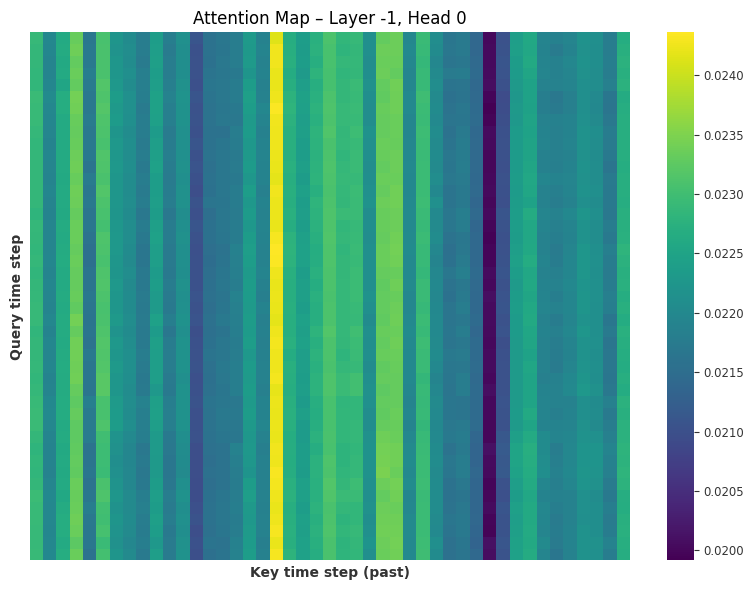

In [ ]:
# ------------------------------------------------------------
# 2) PLOT SINGLE HEAD ATTENTION
# ------------------------------------------------------------

A_head = attn_maps[LAYER_TO_PLOT][0, HEAD_TO_PLOT].cpu().numpy()

plt.figure(figsize=(8, 6))
sns.heatmap(
    A_head,
    cmap="viridis",
    xticklabels=False,
    yticklabels=False
)
plt.title(
    f"Attention Map – Layer {LAYER_TO_PLOT}, Head {HEAD_TO_PLOT}"
)
plt.xlabel("Key time step (past)")
plt.ylabel("Query time step")
plt.tight_layout()
plt.savefig(
    f"{SAVE_DIR}/attention_single_layer{LAYER_TO_PLOT}_head{HEAD_TO_PLOT}_{target_col}.png",
    dpi=200
)
plt.show()


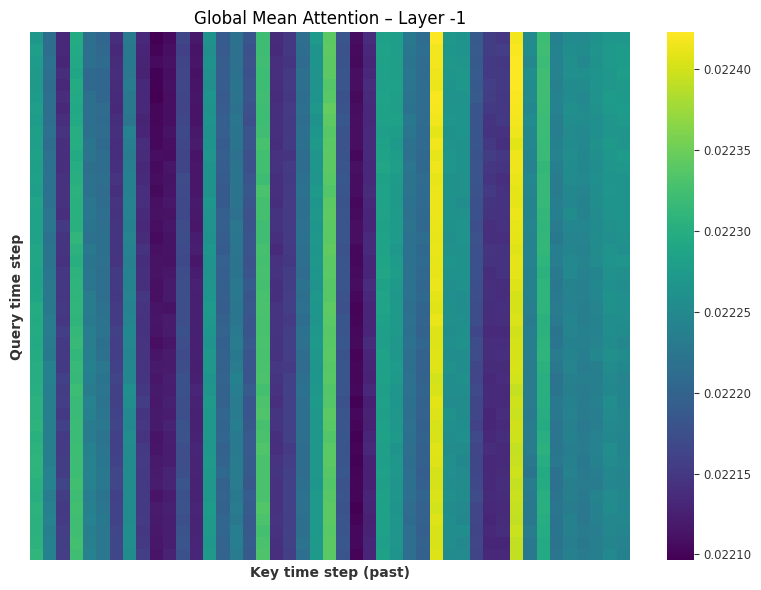

In [13]:
# ============================================================
# 4) GLOBAL ATTENTION (AVERAGED OVER MANY WINDOWS)  [FIXED]
# ============================================================
# AUDIT FIX: the original code averaged attention over ALL-ZERO windows.
# Here we reuse the same valid window logic used above (no leakage).

N_GLOBAL = 80
end_min = T - 1
end_max = len(series_scaled) - H - 1
valid_ends = np.arange(end_min, end_max + 1)

rng = np.random.default_rng(seed)
attn_ends = rng.choice(valid_ends, size=min(N_GLOBAL, len(valid_ends)), replace=False)

ATTN_GLOBAL = []

for end in attn_ends:
    start = end - T + 1
    y_win = series_scaled.values(copy=True)[start:end + 1]
    cov_win = cov_scaled.values(copy=True)[start:end + 1]

    arr = np.concatenate([y_win, cov_win], axis=1)  # (T,F)
    cov_in = arr[:, 1:]  # model sees covariates only

    X_attn = torch.tensor(cov_in, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        attn = get_attention_maps(model, X_attn)

    ATTN_GLOBAL.append(
        attn[LAYER_TO_PLOT][0].mean(axis=0).cpu().numpy()
    )

ATTN_GLOBAL_MEAN = np.mean(ATTN_GLOBAL, axis=0)  # (T,T)

plt.figure(figsize=(8, 6))
sns.heatmap(
    ATTN_GLOBAL_MEAN,
    cmap="viridis",
    xticklabels=False,
    yticklabels=False
)
plt.title(
    f"Global Mean Attention – Layer {LAYER_TO_PLOT}"
)
plt.xlabel("Key time step (past)")
plt.ylabel("Query time step")
plt.tight_layout()
plt.savefig(
    f"{SAVE_DIR}/attention_global_mean_layer{LAYER_TO_PLOT}_{target_col}.png",
    dpi=200
)
plt.show()


In [ ]:
# ============================================================
# GLOBAL TIME × TIME ATTENTION (LAST LAYER, HEADS AVERAGED)
# ============================================================

LAYER = -1
T = window_size
F = 1 + len(feature_cols)

ATTN = []

for i in range(N_GLOBAL):
    arr = X_global[i].reshape(T, F)
    cov_win = arr[:, 1:]

    X = torch.tensor(cov_win, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        attn_maps = get_attention_maps(model, X)
        # attn_maps[layer]: (heads, T, T)
        A = attn_maps[LAYER][0].mean(dim=0)
    # avg over heads → (T,T)

    ATTN.append(A.cpu().numpy())

ATTN_GLOBAL = np.mean(ATTN, axis=0)  # avg over windows → (T,T)

plt.figure(figsize=(8, 6))
sns.heatmap(ATTN_GLOBAL, cmap="viridis")
plt.xlabel("Key time step (past)")
plt.ylabel("Query time step")
plt.title("Global Mean Attention (Time × Time)")
plt.tight_layout()
plt.show()


In [ ]:
# # ============================================================
# HEAD SPECIALIZATION OVER TIME
n_layers = len(attn_maps)

for layer in range(n_layers):
    A = attn_maps[layer][0].cpu().numpy()  # (heads, T, T)
    head_importance = A.mean(axis=2)  # (heads, T)

    plt.figure(figsize=(8, 4))
    sns.heatmap(
        head_importance,
        cmap="viridis",
        yticklabels=[f"Head {i}" for i in range(head_importance.shape[0])],
        xticklabels=False
    )
    plt.xlabel("Past time step")
    plt.ylabel("Attention head")
    plt.title(f"Head specialization – Layer {layer}")
    plt.tight_layout()
    plt.savefig(
        f"plots/attention_head_specialization_layer{layer}_{target_col}_h{test_size}.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.close()




LAYER = 1
n_heads = attn_maps[LAYER].shape[1]
for h in range(n_heads):
    A = attn_maps[LAYER][0, h].cpu().numpy()  # (T_query, T_key)
    var_query = np.mean(np.var(A, axis=0))  # varies by query
    var_key = np.mean(np.var(A, axis=1))  # varies by key
    print(
        f"Head {h}: "
        f"query-var = {var_query:.4e}, "
        f"key-var = {var_key:.4e}"
    )

head_stats = []

n_layers = len(attn_maps)

for L in range(n_layers):
    n_heads = attn_maps[L].shape[1]

    for h in range(n_heads):
        A = attn_maps[L][0, h].cpu().numpy()  # (T_query, T_key)

        query_var = np.mean(np.var(A, axis=0))
        key_var = np.mean(np.var(A, axis=1))
        total_var = query_var + key_var

        head_stats.append({
            "layer": L,
            "head": h,
            "query_var": query_var,
            "key_var": key_var,
            "total_var": total_var
        })

df_heads = (
    pd.DataFrame(head_stats)
    .sort_values("total_var", ascending=False)
    .reset_index(drop=True)
)

print(df_heads.head(10))

# ONE HEAD ATTENTION OVER TIME OF ONE LAYER
LAYER = 1  # which Transformer layer
HEAD = 6  # which attention head

# take ONE window (e.g., the first global window)
arr = X_global[0].reshape(T, F)
cov_win = arr[:, 1:]

X = torch.tensor(cov_win, dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
    attn_maps = get_attention_maps(model, X)
    # attn_maps[layer]: (heads, T, T)
    A_head = attn_maps[LAYER][0, HEAD].cpu().numpy()  # (T, T)

plt.figure(figsize=(8, 6))
sns.heatmap(
    A_head,
    cmap="viridis",
    linewidths=0,  # <<< removes white grid lines
    linecolor=None,
    cbar=True
)

# thin ticks
step = 5  # show one tick every 5 steps
plt.xticks(
    ticks=np.arange(0, T, step),
    labels=np.arange(0, T, step),
    rotation=0
)
plt.yticks(
    ticks=np.arange(0, T, step),
    labels=np.arange(0, T, step),
    rotation=0
)

plt.xlabel("Key time step (past)")
plt.ylabel("Query time step")
plt.title(f"Attention – Layer {LAYER}, Head {HEAD}")
plt.tight_layout()
plt.show()

# ============================================================

In [27]:
x0

array([0.05237376, 0.46930408, 0.5756705 , ..., 1.0134842 , 1.09113924,
       0.27272727], shape=(3600,))

              feature  score_abs_attr_sum_last12
0           CNY Price                   0.083967
1           CLP Price                   0.064155
2       CSI300 Volume                   0.049371
3            Time Idx                   0.041213
4       Total TEU Cys                   0.040380
5     Brent Oil Price                   0.036443
6  Total TEU Ex-Works                   0.035316
7       Total TEU One                   0.034317
8    Total TEU Maersk                   0.032112
9     Total TEU India                   0.030792


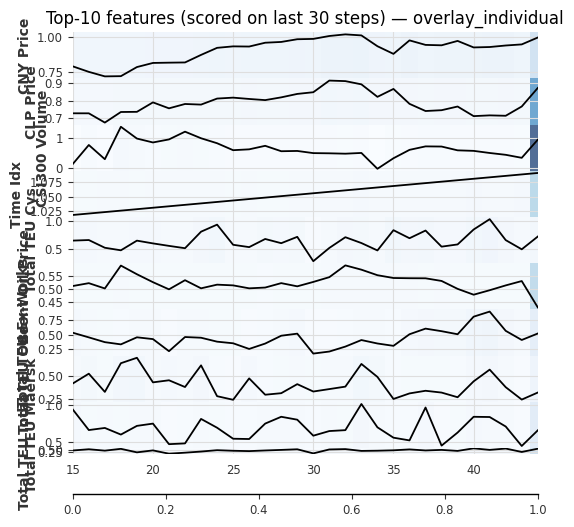

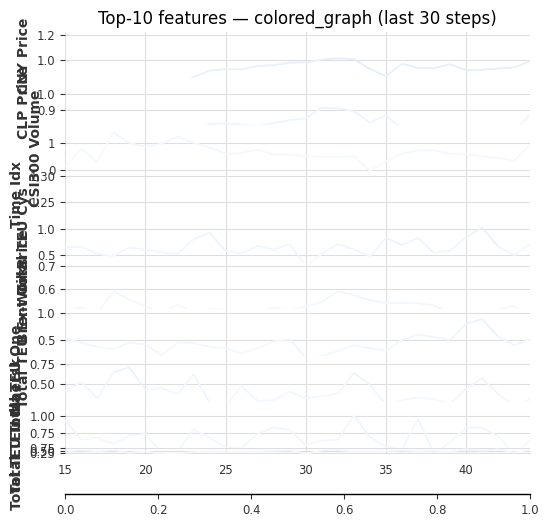

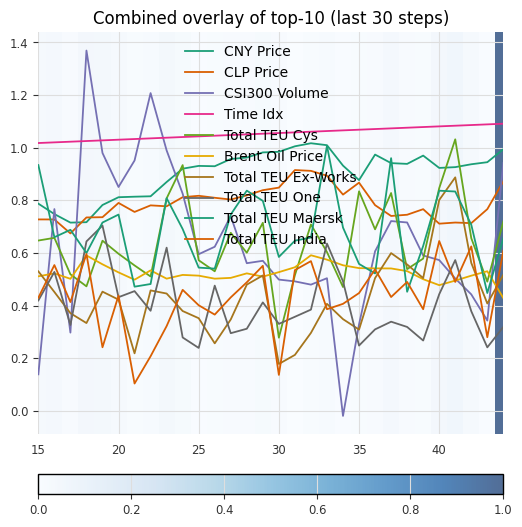

In [40]:
import numpy as np
import torch

from captum.attr import IntegratedGradients  # or Saliency, DeepLift, GradientShap, etc.
from captum.attr import visualization as viz  # has visualize_timeseries_attr


# ----------------------------
# A) YOU must provide these 4 things
# ----------------------------
# 1) model: the trained transformer (nn.Module or LightningModule) in eval mode
#    -> IMPORTANT: run_transformer_with_for_xai must give you access to the trained model.
#       If it doesn't, modify it to also return the best trained model (or checkpoint path + load it).
model = out[0]
assert model is not None, (
    "You need the trained model object. "
    "Modify run_transformer_with_for_xai to return it (e.g., out['model'])."
)

# 2) x_window: ONE input example shaped exactly like the model expects.
#    Common for forecasting transformers: (batch, time, features) == (1, window_size, n_features)
#    -> Ideally this comes from the same dataset/dataloader used in training/testing
# Example placeholder (replace with your real test window tensor):
# x_window = X_test[i:i+1]  # torch.Tensor [1, T, C]
x_window = torch.tensor(cov_hist_np, dtype=torch.float32).unsqueeze(0)
assert x_window.ndim == 3 and x_window.shape[1] == window_size, "Expected [1, T, C]"

# 3) feature_names: list[str] length == n_features (channels)
feature_names = out.get("feature_names", None) if isinstance(out, dict) else None
if feature_names is None:
    feature_names = [f"feat_{j}" for j in range(x_window.shape[-1])]

# 4) x_values: x-axis locations for the window (len == window_size)
#    -> can be np.arange(T) OR actual dates for that window
x_values = np.arange(window_size)


# ----------------------------
# B) Choose device for XAI
# ----------------------------
# Captum gradients sometimes fail on MPS depending on ops; if you hit issues, run XAI on CPU.
xai_device = torch.device("cpu")
model = model.to(xai_device).eval()
x_window = x_window.to(xai_device).float()

# Baseline: what "no signal" means for your model
# Options: zeros, mean window, last value repeated, etc.
baseline = torch.zeros_like(x_window)


# ----------------------------
# C) Define "forward for one horizon"
# ----------------------------
# You want a scalar output so Captum doesn't need a target index.
# Assumption: model(x) -> [B, H] (multi-horizon forecast).
HORIZON = HORIZON_TO_EXPLAIN  # from your code, e.g. H-1

def forward_one_horizon(x):
    y_hat = model(x)          # expected shape [B, H]
    return y_hat[:, HORIZON]  # shape [B]  (scalar per example)

# Pick an attribution method
ig = IntegratedGradients(forward_one_horizon)

# Compute attributions: same shape as x_window: [1, T, C]
attr = ig.attribute(
    x_window,
    baselines=baseline,
    n_steps=64,              # IG steps (trade speed vs smoothness)
)

# Convert for Captum timeseries viz:
# visualize_timeseries_attr expects numpy arrays shape (N, C) by default (channels_last=True)
attr_np = attr.squeeze(0).detach().cpu().numpy()       # (T, C)
data_np = x_window.squeeze(0).detach().cpu().numpy()   # (T, C)

T, C = attr_np.shape
real_feature_names = list(map(str, feature_cols))  # <-- your real names
assert len(real_feature_names) == C, (
    f"Name mismatch: len(feature_cols)={len(real_feature_names)} but attr has C={C} channels. "
    "If this fails, your feature ordering / selection changed between training and x_window."
)
real_feature_names = rename_specific([prettify(n) for n in real_feature_names])
TOP_K = 10
PAST_STEPS = 30  # "score the past 12 time steps"

T, C = attr_np.shape
assert data_np.shape == (T, C)
assert len(feature_names) == C
assert len(x_values) == T

# 1) Score each feature using attribution magnitude in the last PAST_STEPS
tail = slice(max(0, T - PAST_STEPS), T)  # robust if PAST_STEPS > T
feat_scores = np.sum(np.abs(attr_np[tail, :]), axis=0)  # (C,)

top_idx = np.argsort(feat_scores)[::-1][:TOP_K]
top_names = [real_feature_names[i] for i in top_idx]

# Optional: print a tidy ranking table
rank_df = pd.DataFrame({
    "feature": top_names,
    "score_abs_attr_sum_last12": feat_scores[top_idx],
}).reset_index(drop=True)
print(rank_df)

# 2) Slice arrays to (last 12 steps) x (top 10 features)
attr_top = attr_np[tail, :][:, top_idx]   # (<=12, 10)
data_top = data_np[tail, :][:, top_idx]   # (<=12, 10)
x_top = np.array(x_values)[tail]            # (<=12,)

# 3) Visualize (much less busy)
fig1, ax1 = viz.visualize_timeseries_attr(
    attr=attr_top,
    data=data_top,
    x_values=x_top,
    method="overlay_individual",       # best when you want feature-by-feature
    sign="absolute_value",
    channel_labels=top_names,
    channels_last=True,
    show_colorbar=True,
    title=f"Top-{TOP_K} features (scored on last {PAST_STEPS} steps) — overlay_individual",
    alpha_overlay=0.7,
    use_pyplot=True,
)

fig2, ax2 = viz.visualize_timeseries_attr(
    attr=attr_top,
    data=data_top,
    x_values=x_top,
    method="colored_graph",            # often the cleanest for quick reads
    sign="absolute_value",
    channel_labels=top_names,
    channels_last=True,
    show_colorbar=True,
    title=f"Top-{TOP_K} features — colored_graph (last {PAST_STEPS} steps)",
    use_pyplot=True,
)

# If you want a *single* compact plot, overlay_combined merges channels (less interpretable per feature):
fig3, ax3 = viz.visualize_timeseries_attr(
    attr=attr_top,
    data=data_top,
    x_values=x_top,
    method="overlay_combined",
    sign="absolute_value",
    channel_labels=top_names,
    channels_last=True,
    show_colorbar=True,
    title=f"Combined overlay of top-{TOP_K} (last {PAST_STEPS} steps)",
    alpha_overlay=0.7,
    use_pyplot=True,
)

In [41]:
T_top = len(x_top)
time_labels = [f"t-{T_top-1-i}" for i in range(T_top)]

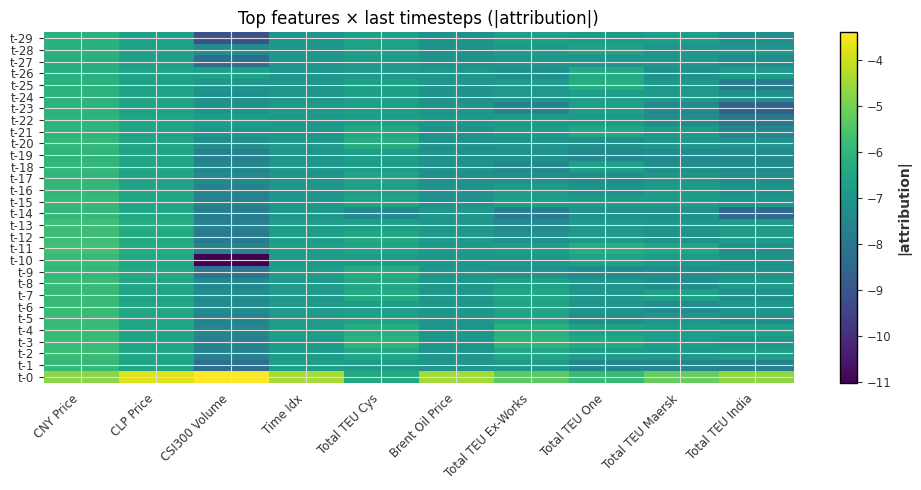

In [42]:
import matplotlib.pyplot as plt
import numpy as np

A = np.log(np.abs(attr_top) + 1e-8)  # shape (<=12, top_k)

plt.figure(figsize=(10, 5))
plt.imshow(A, aspect="auto", interpolation="nearest")
plt.yticks(range(A.shape[0]), time_labels)                 # <-- LIME-ish lag labels
plt.xticks(range(A.shape[1]), top_names, rotation=45, ha="right")  # <-- feature names
plt.colorbar(label="|attribution|")
plt.title("Top features × last timesteps (|attribution|)")
plt.tight_layout()
plt.show()


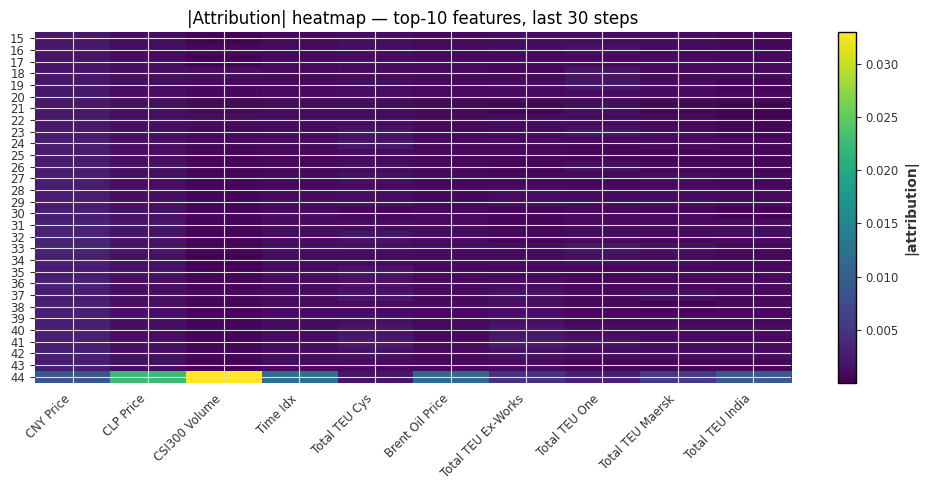

In [46]:
import matplotlib.pyplot as plt

# magnitude heatmap: rows=time, cols=features
A = np.abs(attr_top)  # (<=12, 10)

plt.figure(figsize=(10, 5))
plt.imshow(A, aspect="auto", interpolation="nearest")
plt.yticks(range(A.shape[0]), [str(x) for x in x_top])
plt.xticks(range(A.shape[1]), top_names, rotation=45, ha="right")
plt.colorbar(label="|attribution|")
plt.title(f"|Attribution| heatmap — top-{TOP_K} features, last {PAST_STEPS} steps")
plt.tight_layout()
plt.show()


In [35]:
feat_scores = np.sum(np.abs(attr_np), axis=0)
feat_scores

array([2.19774519e-02, 1.27305069e-02, 2.03896011e-02, 2.90520723e-02,
       1.93341425e-02, 7.49512082e-03, 3.05787758e-03, 3.00964379e-03,
       1.16492631e-02, 1.60539333e-02, 2.26627267e-02, 8.39977459e-03,
       7.66889059e-03, 2.98853935e-02, 1.31082805e-02, 2.64643361e-02,
       1.76467972e-02, 8.83482358e-03, 2.64763688e-03, 9.13445689e-03,
       2.80045894e-02, 2.00382422e-02, 1.03618944e-02, 7.82833575e-03,
       6.87082533e-03, 4.15273881e-02, 2.10611154e-02, 5.58946223e-03,
       1.17160357e-02, 1.53738821e-02, 6.07703305e-03, 2.50537378e-02,
       1.22811137e-02, 1.65136575e-02, 1.03463230e-03, 6.92091000e-03,
       1.29069995e-02, 8.54267411e-06, 4.74973942e-02, 5.19610884e-02,
       1.40420474e-02, 2.19805134e-03, 6.07161774e-02, 5.22184610e-02,
       1.13060846e-02, 1.20925180e-02, 1.26129101e-02, 1.69537788e-03,
       3.81421730e-02, 9.63505620e-03, 8.21955493e-03, 3.69073642e-03,
       9.61644771e-03, 5.49054955e-03, 2.31240815e-02, 1.23850348e-02,
      